<hr/>
<h1>7. Interpretation Of Clusters</h1>

<p>In this section, I will be interpreting the Clusters and finding out why certain data points are determined as a cluster and the average and key features that differentiate a cluster from another cluster. There will be multiple analysis done in this section and also visualisations.</p>

<hr/>
<h2>7.1 Reversing Scaling</h2>

<p>In order to interpret our clustering effectively and accurately, we will firstly need to reverse the Z-Score Standardisation that was previously applied to the data. This will allow us to get back the original values for each of the data which removes the need for guessing the initial value. This operation will be done in the cell below.</p>

In [196]:
# ---------- Inverse Scaling ---------- #
df_zscore[features_to_scale] = scaler_zscore.inverse_transform(df_zscore[features_to_scale])

# ----------- Dropping t-SNE Data Columns ---------- #
df_zscore.drop(["TSNE1", "TSNE2"], axis=1, inplace=True)

# ---------- Displaying DataFrame ---------- #
df_zscore.head(5).style.background_gradient(cmap="Blues")

,Age,Income (k$),How Much They Spend,Gender_Male,Cluster
0,19.000000,15.000000,39.000000,1,5
1,21.000000,15.000000,81.000000,1,5
2,20.000000,16.000000,6.000000,0,0
3,23.000000,16.000000,77.000000,0,5
4,31.000000,17.000000,40.000000,0,0


<p>With reference to the output of the DataFrame above, I am able to confirm that the Data have been successfully reverse scaled and are more interpretable now.</p>

<hr/>
<h2>7.2 Decision Tree Interpretation</h2>

<p>In this sub-section, I will be plotting out the Decision Tree plot to analyse and interpret what causes a certain data to be clustered under a specific cluster. This will provide some insights on an unsupervised model and also give us an opportunity to try to interpret what are the key deciding factors for clusters. We will be putting the target as Y and the features as X.</p>

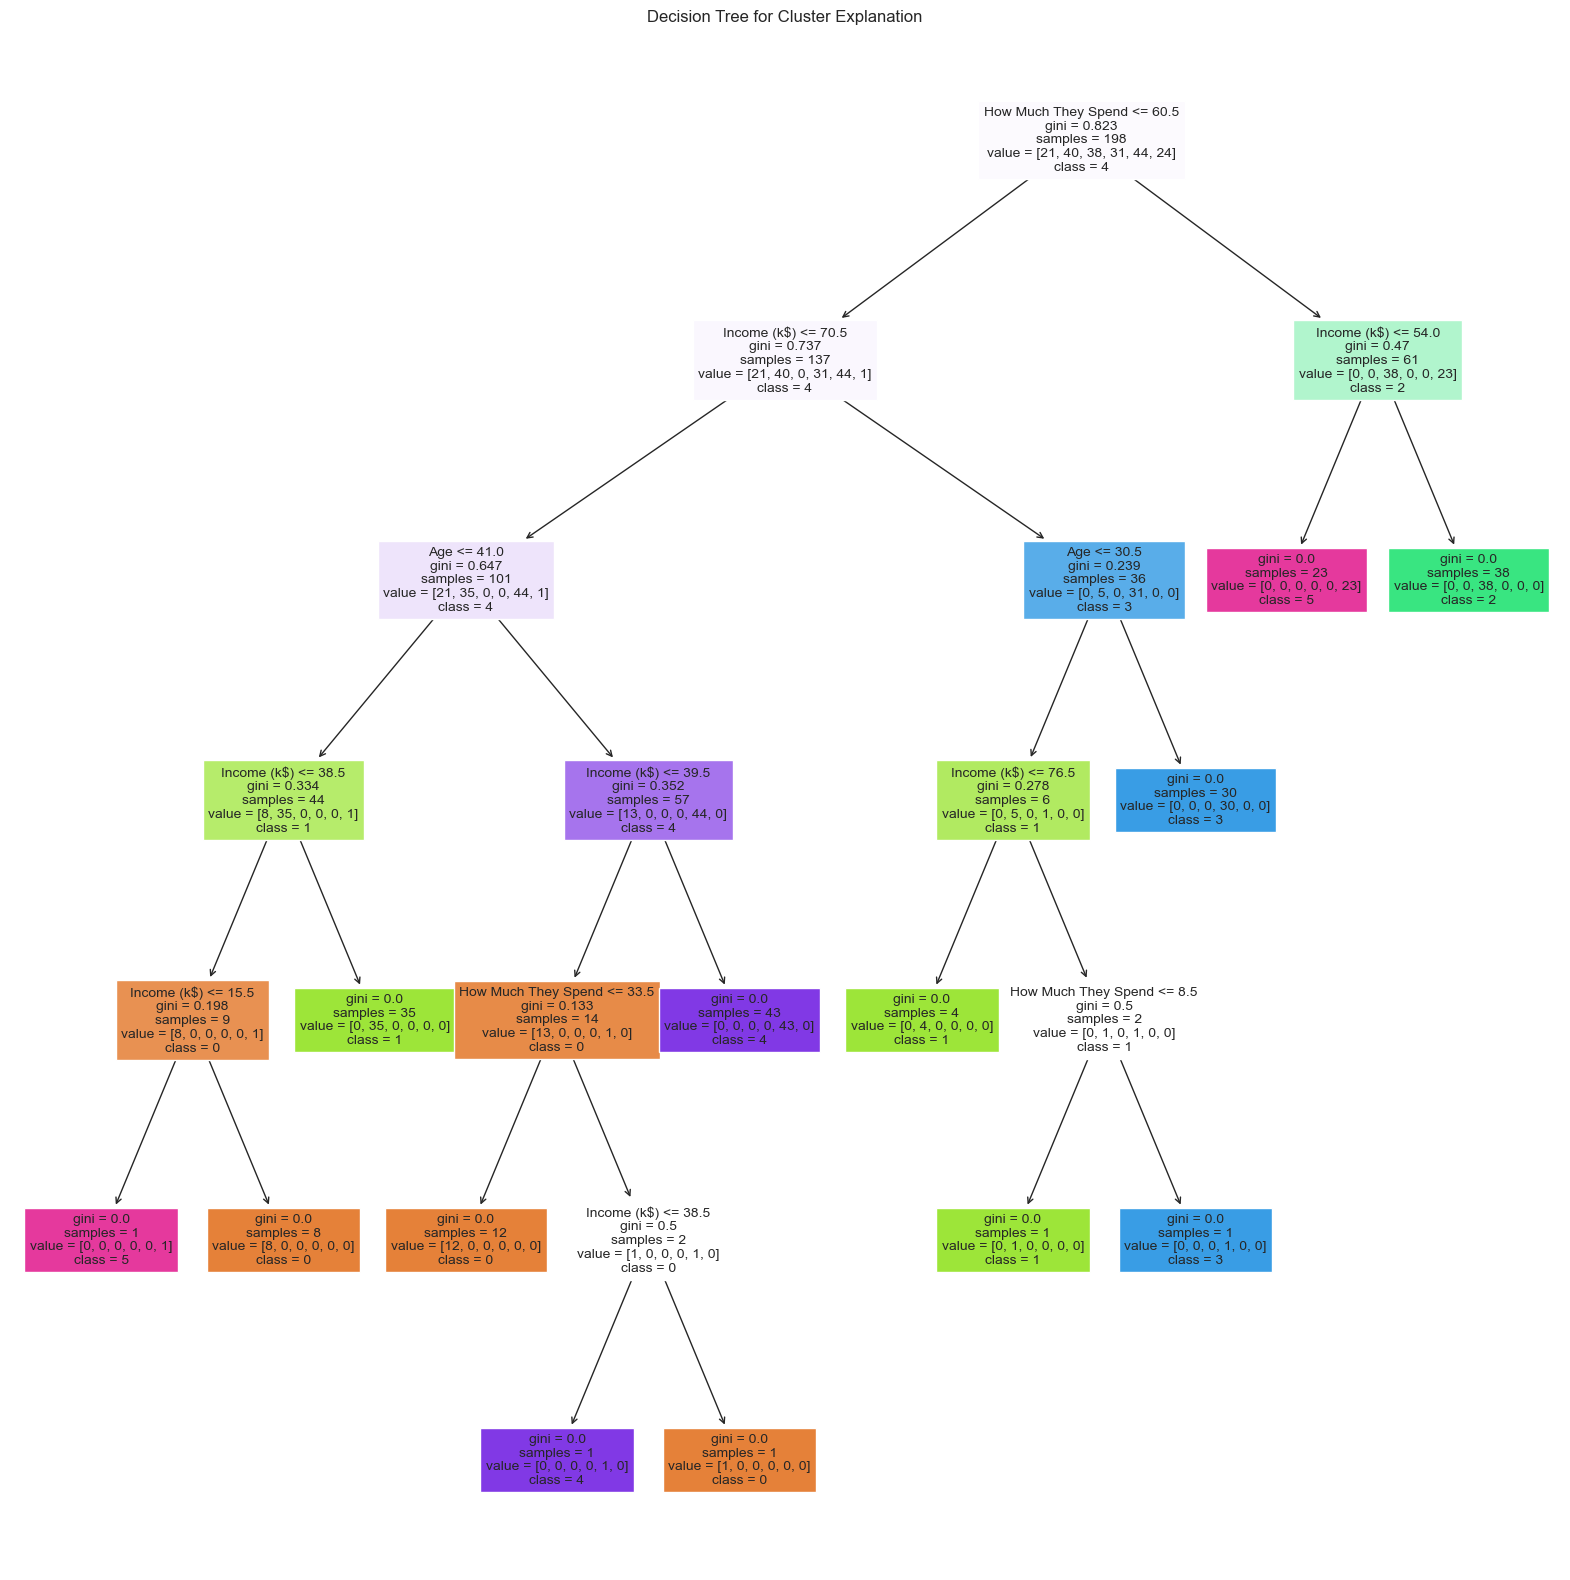

In [200]:
# ----------- Data Preparation ----------- #
X = df_zscore[features_to_scale]
y = df_zscore['Cluster']

# ----------- Initiating Decision Tree Classifier ------------ #
dtree = DecisionTreeClassifier(random_state=42, max_depth=6)

# ----------- Training Decision Tree Classifier ------------ #
dtree.fit(X, y)

# ---------- Plotting Decision Tree ---------- #
plt.figure(figsize=(20, 20))
plot_tree(dtree, feature_names=features_to_scale, class_names=[str(c) for c in set(y)], filled=True, fontsize=10)
plt.title("Decision Tree for Cluster Explanation")
plt.show()

<p>With reference to the output of the Decision Tree plot above, I am able to see how are the clusters being clustered by the K-Means. The observations are listed below.</p>
<br/>
<p><strong><u>Splits</u></strong></p>
<ul>
    <li>The most important split which is the major deciding factor is the 'How much they spend'. This means Customers who spend more than 60.5 are immediately either placed in Cluster 2 or 5. This suggest spending plays a crucial role in the clustering.</li>
    <li>The second most important split is based on the 'Income (k$)'. This imply that higher income groups are separated from lower income groups with threshold of 70.5k, 54k, etc.</li>
    <li>The third most important split is based on the 'Age'. This implies that demographics are not as important as monetary value.</li>
</ul>
<p><strong><u>Clusters Interpretation</u></strong></p>
<ul>
    <li>Cluster 0: Lowest Income-Group With Lowest Spending (21 Customers)</li>
    <li>Cluster 1: Younger Demographic With Moderate Income With Moderate Spending (40 Customers)</li>
    <li>Cluster 2: High Income And High Spending (38 Customers)</li>
    <li>Cluster 3: High Income Group With Low Spending (31 Customers)</li>
    <li>Cluster 4: Older Demographic With Moderate Income And Moderate Spending (44 Customers)</li>
    <li>Cluster 5: Low Income With High Spending (24 Customers)</li>
</ul>
<br/>
<p>With the clustering factors and each cluster's representation indcated, I will proceed with gathering Implications and Insights on each of the clusters.</p>

<hr/>
<h1>8. Implications And Insights Of Clusters</h1>

<p>In this section, I will be gathering Insights and listing their Implications for businesses. This will help our stakeholders improve their customer quality and also possibly improve their profit margins so as to divert manpower resources and utilising other methods and resources to create a contingency plan to cater to the different clusters of Customers.</p>

<hr/>
<h2>8.1 Ratio Of Clusters</h2>

<p>Within this sub-section, I will be visualising the ratio of Clusters to see which clusters has the most amount of Customers so as to decide which Clusters need the most resources and planning so as to cater to the customers within that cluster. I will be utilising a Pie Chart so as to also compare with the rest of the Clusters.</p>

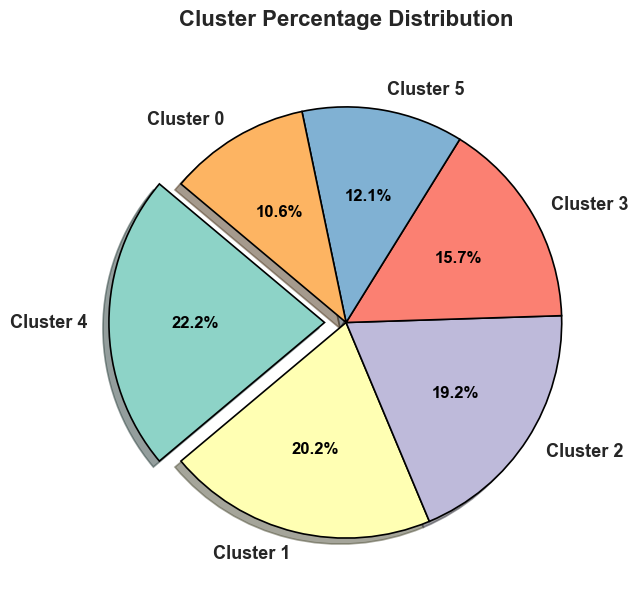

In [206]:
# ----------- Seaborn Theme ----------- #
sns.set_theme(style="whitegrid")

# ----------- Get Cluster Counts ----------- #
cluster_counts = df_zscore['Cluster'].value_counts()

# ----------- Defining Colour Palette ----------- #
colors = sns.color_palette("Set3", len(cluster_counts))

# ----------- Exploding Highest Counts ----------- #
explode = [0.1 if i == cluster_counts.idxmax() else 0 for i in cluster_counts.index]

# ----------- Plotting Pie Chart ----------- #
fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    cluster_counts, labels=[f"Cluster {i}" for i in cluster_counts.index], autopct='%1.1f%%',
    startangle=140, colors=colors, explode=explode, shadow=True,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2}, textprops={'fontsize': 12}
)

# ----------- Text And Labels ----------- #
for text in texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('black')

# ----------- Add Title ----------- #
ax.set_title("Cluster Percentage Distribution", fontsize=16, fontweight='bold', pad=20)

# ----------- Displaying Plot ----------- #
plt.show()


<p>With reference to the Pie Chart above, I am able to see that Cluster 4 makes up the most percentage at 22.2% followed by Cluster 1 at 20.2% and Cluster 2 at 19.2%. These three clusters form the majority of the Total Dataset and should be paid close attention to due to it being 61.4% of the data. I have listed the implications below.</p>
<br/>
<p><strong><u>Cluster 4</u></strong></p>
<ul>
    <li>Cluster Properties: Older Demographic With Moderate Income And Moderate Spending.</li>
    <li>Cluster 4 represents the older mainstream customers who do not spend much but still spends.</li>
    <li>Most Manpower should be dedicated to assisting and catering to these Customers as most of the revenue will come from them due to their large numbers.</li>
    <li>A mixture of experienced and less experienced should be allowed to handle Customers from Cluster 4.</li>
    <li>Manpower should be distributed on a need basis for Customer from Cluster 4 (e.g. A staff helps the customer whenever he is available).</li>
    <li>Manpower will need to be sufficient at each outlet as the Older Demographic will prefer purchasing items in person.</li>
</ul>
<p><strong><u>Cluster 1</u></strong></p>
<ul>
    <li>Cluster Properties: Younger Demographic With Moderate Income With Moderate Spending.</li>
    <li>Cluster 1 represents the younger mainstream customers who do not spend much but still spends.</li>
    <li>Manpower should be distributed the least for Customers who are in this Cluster as the revenue from these Customers are extremely minimal despite being a large part of the total Customer population. However, a high standard of Hospitality and Customer Service Excellence should still be maintained.</li>
    <li>A reward's programme can be set up so as to transition Customers who are Clustered as Cluster 1 to Cluster 2, so as to increase the revenue earned from these Customers.</li>
    <li>May be more responsive towards an online shopping portal due to the younger demographic.</li>
</ul>
<p><strong><u>Cluster 2</u></strong></p>
<ul>
    <li>Cluster Properties: High Income And High Spending</li>
    <li>Cluster 2 Customers hold the highest priority as these Customers bring in the most revenue.</li>
    <li>Only experienced Customer Engagement Officer should engage these customers to ensure the highest of standards of Customer Service are provided to these Customers.</li>
    <li>High Quality or Limited Edition items should be introduced so as to capture the attention of these Customers and allow for higher profit margin within the companny from Sales as these Customers also have higher spending power.</li>
</ul>
<br/>
<p>With the Cluster Percentage Distribution's observation and implication stated, I will now proceed to visualise the distribution of various data across clusters.</p>

<hr/>
<h2>8.2 Distribution Of Age Across Clusters</h2>

<p>In this sub-section, we will be visualising the distribution of Age across the different Clusters so as to determine if a specific age group should be targetted. I will be utilising a Box Plot to see the distribution and will subsequently list down the age range for each of the clusters and also the </p>

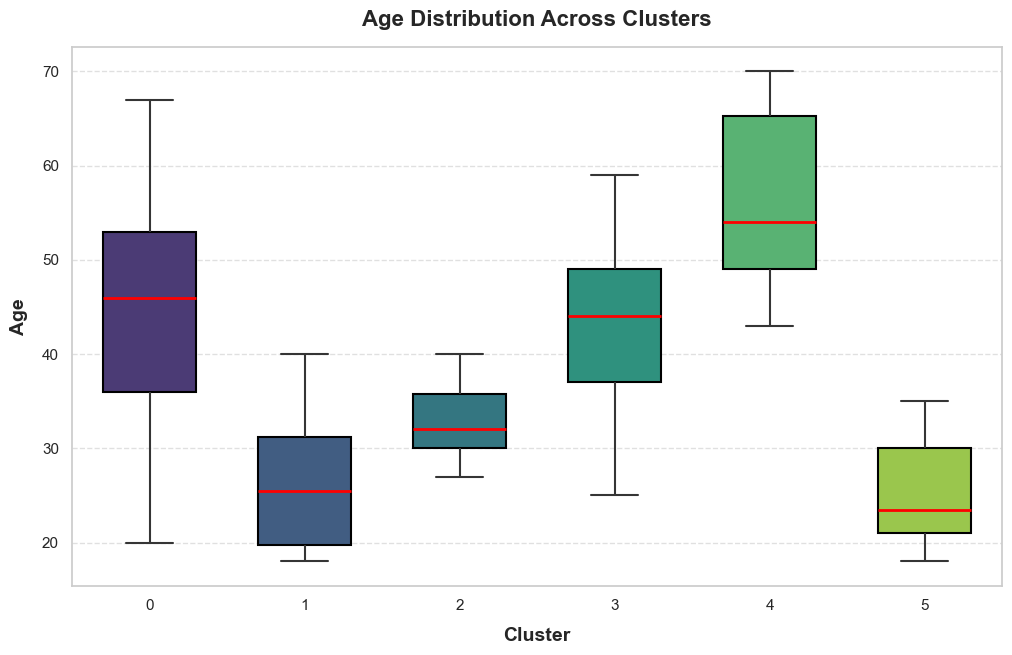

In [210]:
# ----------- Seaborn Theme ----------- #
sns.set_theme(style="whitegrid")

# ----------- Defining Figure ----------- #
plt.figure(figsize=(12, 7))

# ----------- Enhanced Boxplot ----------- #
sns.boxplot(
    x='Cluster', y='Age', data=df_zscore, 
    palette='viridis', width=0.6, linewidth=1.5, 
    boxprops={'edgecolor': 'black', 'linewidth': 1.5},
    medianprops={'color': 'red', 'linewidth': 2}
)

# ----------- Titles And Labels ----------- #
plt.title("Age Distribution Across Clusters", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Cluster", fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel("Age", fontsize=14, fontweight='bold', labelpad=10)

# ----------- Adding Grid ----------- #
plt.grid(axis='y', linestyle='--', alpha=0.6)

# ----------- Displaying Plot ----------- #
plt.show()

<p>With reference to the output of the Box plot above, I am able to see the range of ages and median age for each of the Clusters. The observations and implications are listed below.</p>
<br/>
<p><strong><u>Cluster 0</u></strong></p>
<ul>
    <li>Properties: Lowest Income-Group With Lowest Spending</li>
    <li>Range of Age: 20 to 67 Years Old</li>
    <li>Median Age: 46 Years Old</li>
</ul>
<p><strong><u>Cluster 1</u></strong></p>
<ul>
    <li>Properties: Younger Demographic With Moderate Income With Moderate Spending</li>
    <li>Range of Age 18 to 40 Years Old</li>
    <li>Median Age: 25 Years Old</li>
</ul>
<p><strong><u>Cluster 2</u></strong></p>
<ul>
    <li>Properties: High Income And High Spending</li>
    <li>Range of Age: 27 to 40 Years Old</li>
    <li>Median Age: 32 Years Old</li>
</ul>
<p><strong><u>Cluster 3</u></strong></p>
<ul>
    <li>Properties: High Income Group With Low Spending</li>
    <li>Range of Age: 25 to 59 Years Old</li>
    <li>Median Age: 45 Years Old</li>
</ul>
<p><strong><u>Cluster 4</u></strong></p>
<ul>
    <li>Properties: Older Demographic With Moderate Income And Moderate Spending</li>
    <li>Range of Age: 43 to 70 Years Old</li>
    <li>Median Age: 54 Years Old</li>
</ul>
<p><strong><u>Cluster 5</u></strong></p>
<ul>
    <li>Properties: Low Income With High Spending</li>
    <li>Range of Age: 18 to 35 Years Old</li>
    <li>Median Age: 24 Years Old</li>
</ul>
<br/>
<p>With reference to the range of ages, I am able to make the following business implications</p>
<br/>
<ul>
    <li>High Spenders who will bring in large amount of profits are aged 18 Years Old to 40 Years Old. Therefore, more attention should be paid to these Customers as these Customers bring in the highest profit margin for the company and also most likely more demanding than other Customers. Thus, more experienced staff should be on standby to entertain and engage these Customers to ensure their satisfaction and potentially upselling to these Customers.</li>
    <li>Some staff should be on stand by to cater to a potential high value customer while most of the staff engage with Customers in general.</li>
    <li>Staff should not discriminate against the age of any Customers as the range of Customers who spends money in general is from 18 to 70 Years Old.</li>
    <li>Companies should consider adopting a hybrid approach to selling items such as utilising Online Shopping Platforms and Social Media as the median age of High Spenders are around 23 and 32 Years Old, which means these demographics most likely prefer purchasing items through Online Shopping rather than in-person.</li>
    <li>Staff should look out for Customers aged 24 and 32 as these are the Median age for high spending customers.</li>
</ul>
<br/>
<p>With the Implications indicated, I will proceed to conduct the Visualisation on the Income Distribution in the next sub-section.</p>

<hr/>
<h2>8.3 Distribution Of Income Across Clusters</h2>

<p>In this sub-section, we will be visualising the distribution of Income across the different Clusters so as to determine if a specific age group should be targetted. I will be utilising a Box Plot to see the distribution and will subsequently list down the age range for each of the clusters and also the </p>

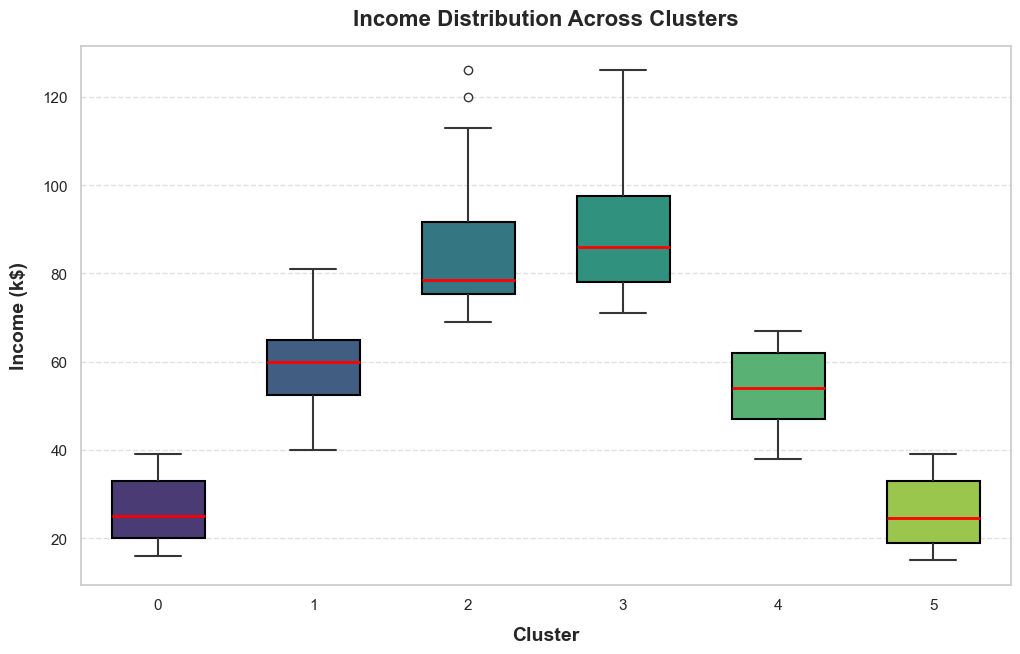

In [214]:
# ----------- Seaborn Theme ----------- #
sns.set_theme(style="whitegrid")

# ----------- Defining Figure ----------- #
plt.figure(figsize=(12, 7))

# ----------- Plotting Boxplots ----------- #
sns.boxplot(
    x='Cluster', y='Income (k$)', data=df_zscore, 
    palette='viridis', width=0.6, linewidth=1.5, 
    boxprops={'edgecolor': 'black', 'linewidth': 1.5},  # Darker borders
    medianprops={'color': 'red', 'linewidth': 2}  # Highlight median in red
)

# ----------- Titles And Labels ----------- #
plt.title("Income Distribution Across Clusters", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Cluster", fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel("Income (k$)", fontsize=14, fontweight='bold', labelpad=10)

# ----------- Adding Grid ----------- #
plt.grid(axis='y', linestyle='--', alpha=0.6)

# ----------- Displaying Plot ----------- #
plt.show()

<p>With reference to the output of the Box plot above, I am able to see the range of Income and median Income for each of the Clusters. The observations and implications are listed below.</p>
<br/>
<p><strong><u>Cluster 0</u></strong></p>
<ul>
    <li>Properties: Lowest Income-Group With Lowest Spending</li>
    <li>Range of Age: 20 to 67 Years Old</li>
    <li>Median Age: 46 Years Old</li>
    <li>Range of Income: 18k to 39k</li>
    <li>Median Income: 25k</li>
</ul>
<p><strong><u>Cluster 1</u></strong></p>
<ul>
    <li>Properties: Lower Income With Lower Spending</li>
    <li>Range of Age 18 to 40 Years Old</li>
    <li>Median Age: 25 Years Old</li>
    <li>Range of Income: 40k to 81k</li>
    <li>Median Income: 60k</li>
</ul>
<p><strong><u>Cluster 2</u></strong></p>
<ul>
    <li>Properties: High Income And High Spending</li>
    <li>Range of Age: 27 to 40 Years Old</li>
    <li>Median Age: 32 Years Old</li>
    <li>Range of Income: 70k to 130k</li>
    <li>Median Income: 79k</li>
</ul>
<p><strong><u>Cluster 3</u></strong></p>
<ul>
    <li>Properties: Young Individuals With Medium Income And Spending</li>
    <li>Range of Age: 25 to 59 Years Old</li>
    <li>Median Age: 45 Years Old</li>
    <li>Range of Income: 70k to 130k</li>
    <li>Median Income: 84k</li>
</ul>
<p><strong><u>Cluster 4</u></strong></p>
<ul>
    <li>Properties: Moderate Spenders And Medium Income Range</li>
    <li>Range of Age: 43 to 70 Years Old</li>
    <li>Median Age: 54 Years Old</li>
    <li>Range of Income: 38k to 68k</li>
    <li>Median Income: 56k</li>
</ul>
<p><strong><u>Cluster 5</u></strong></p>
<ul>
    <li>Properties: Very High Spenders With Very Low Income</li>
    <li>Range of Age: 18 to 35 Years Old</li>
    <li>Median Age: 24 Years Old</li>
    <li>Range of Income: 18k to 39k</li>
    <li>Median Income: 25k</li>
</ul>
<br/>
<p>With reference to the range of ages, I am able to make the following business implications</p>
<br/>
<ul>
    <li>The high spenders have a range on income of 40k to 130k, with median being 79k. This shows the amount of spending power these individuals have which implies that Customer Service Officers should look out for customers in the age range of 27 to 40 Years old and especially for Customers who are in their 30s since the median age is 32 Years Old.</li>
    <li>Customers Service Officers should also take note that Genders are clustered together. Therefore, it is extremely important not to discriminate against a particular Gender.</li>
    <li>Customers in Cluster 0 and Cluster 5 have the lowest median income. However, cluster 5 is determined to have a high spending, which indicates that payment made need to be cautious in the event that the payment method is not approved.</li>
</ul>
<br/>
<p>With the Implications indicated, I will proceed to conduct the Visualisation on the Spending Distribution in the next sub-section.</p>

<hr/>
<h2>8.4 Distribution Of Spending Across Clusters</h2>

<p>In this sub-section, we will be visualising the distribution of Spending across the different Clusters so as to determine if a specific age group should be targetted. I will be utilising a Box Plot to see the distribution and will subsequently list down the age range for each of the clusters and also the </p>

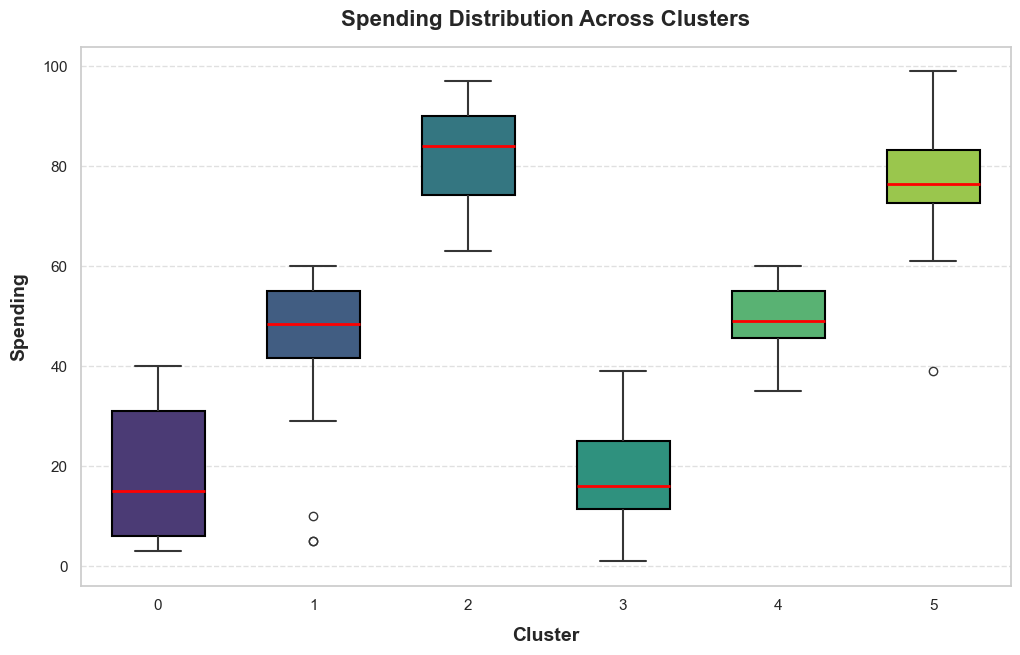

In [218]:
# ----------- Seaborn Theme ----------- #
sns.set_theme(style="whitegrid")

# ----------- Defining Figure Size ----------- #
plt.figure(figsize=(12, 7))

# ----------- Plotting Boxplot ----------- #
sns.boxplot(
    x='Cluster', y='How Much They Spend', data=df_zscore, 
    palette='viridis', width=0.6, linewidth=1.5, 
    boxprops={'edgecolor': 'black', 'linewidth': 1.5},  # Darker borders
    medianprops={'color': 'red', 'linewidth': 2}  # Highlight median in red
)

# ----------- Titles And Labels ----------- #
plt.title("Spending Distribution Across Clusters", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Cluster", fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel("Spending", fontsize=14, fontweight='bold', labelpad=10)

# ----------- Adding Grid ----------- #
plt.grid(axis='y', linestyle='--', alpha=0.6)

# ----------- Displaying Plot ----------- #
plt.show()

<p>With reference to the output of the Box plot above, I am able to see the range of Income and median Income for each of the Clusters. The observations and implications are listed below.</p>
<br/>
<p><strong><u>Cluster 0</u></strong></p>
<ul>
    <li>Properties: Lowest Income-Group With Lowest Spending</li>
    <li>Range of Age: 20 to 67 Years Old</li>
    <li>Median Age: 46 Years Old</li>
    <li>Range of Income: 18k to 39k</li>
    <li>Median Income: 25k</li>
    <li>Range of Spending: 2 to 40</li>
    <li>Median Spending 17</li>
</ul>
<p><strong><u>Cluster 1</u></strong></p>
<ul>
    <li>Properties: Lower Income With Lower Spending</li>
    <li>Range of Age 18 to 40 Years Old</li>
    <li>Median Age: 25 Years Old</li>
    <li>Range of Income: 40k to 81k</li>
    <li>Median Income: 60k</li>
    <li>Range of Spending: 5 to 60</li>
    <li>Median Spending 17</li>
</ul>
<p><strong><u>Cluster 2</u></strong></p>
<ul>
    <li>Properties: High Income And High Spending</li>
    <li>Range of Age: 27 to 40 Years Old</li>
    <li>Median Age: 32 Years Old</li>
    <li>Range of Income: 70k to 130k</li>
    <li>Median Income: 79k</li>
    <li>Range of Spending: 62 to 95</li>
    <li>Median Spending 17</li>
</ul>
<p><strong><u>Cluster 3</u></strong></p>
<ul>
    <li>Properties: Young Individuals With Medium Income And Spending</li>
    <li>Range of Age: 25 to 59 Years Old</li>
    <li>Median Age: 45 Years Old</li>
    <li>Range of Income: 70k to 130k</li>
    <li>Median Income: 84k</li>
    <li>Range of Spending: 1 to 39</li>
    <li>Median Spending 17</li>
</ul>
<p><strong><u>Cluster 4</u></strong></p>
<ul>
    <li>Properties: Moderate Spenders And Medium Income Range</li>
    <li>Range of Age: 43 to 70 Years Old</li>
    <li>Median Age: 54 Years Old</li>
    <li>Range of Income: 38k to 68k</li>
    <li>Median Income: 56k</li>
    <li>Range of Spending: 35 to 60</li>
    <li>Median Spending 17</li>
</ul>
<p><strong><u>Cluster 5</u></strong></p>
<ul>
    <li>Properties: Very High Spenders With Very Low Income</li>
    <li>Range of Age: 18 to 35 Years Old</li>
    <li>Median Age: 24 Years Old</li>
    <li>Range of Income: 18k to 39k</li>
    <li>Median Income: 25k</li>
    <li>Range of Spending: 39 to 99</li>
    <li>Median Spending 17</li>
</ul>
<br/>
<p>With reference to the range of ages, I am able to make the following business implications</p>
<br/>
<ul>
    <li>Despite some clusters having a small range of spending, the Customers are still spending money. Therefore, Customer Service Officers should not be discriminating against anyone as all the customers are still spending money which contributes to the total revenue.</li>
    <li>Customer Service Officers should take note of Customers who fall under the Cluster 3 as these Customers are spending very little but they have the spending power. Therefore, upselling techniques should be used by staff to try to increase revenue..</li>
    <li>Some Clusters may have outliers within them such as Cluster 1 which indicates that despite the Clusterign to boost revenue, there will still be exceptions and the staff should ultimately exercise discretion when dealing with Customers.</li>
</ul>
<br/>
<p>With the Implications indicated, I hereby conclude the Part B of CA 2.</p>